# Stream Station Validation

Classifies the 11 held-out stream stations using the typology trained in
`ss-typology.ipynb`. Each site is standardized with the saved scaler, projected
into the trained PCA space, and assigned to its **nearest cluster centroid** —
no refitting, so there is no data leakage. Nearest-centroid assignment works
whether the typology was built with Ward or k-means.

Pipeline: **load model → data input → project & classify → characterization.**

> Run `ss-typology.ipynb` first to produce `results/typology-model.joblib`.

In [1]:
# --- Setup & load the trained typology ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from scipy.spatial.distance import cdist

ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "bin" else ROOT
DATA = ROOT / "data" / "tidy" / "MA_Combined_streams_TP_soil_LULC_within_50m(in).csv"
OUT = ROOT / "results"        # data artifacts: CSV + joblib
FIG = ROOT / "figures"        # all plots
FIG.mkdir(exist_ok=True)

# Larger fonts to match the typology figures
plt.rcParams.update({"axes.labelsize": 15, "xtick.labelsize": 12,
                     "ytick.labelsize": 12, "legend.fontsize": 11})

M = joblib.load(OUT / "typology-model.joblib")
scaler, pca = M["scaler"], M["pca"]
centroids = M["centroids"]
FEATURES, ID_COLS = M["features"], M["id_cols"]
PC_NAMES, VARIABLE_LABELS = M["pc_names"], M["variable_labels"]
CLUSTER_NAMES = M["cluster_names"]
N = M["n_pcs_cluster"]
PALETTE = list(plt.get_cmap("tab10").colors)
print(f"Loaded typology: method={M['cluster_method']}, K={M['k']}, "
      f"clustering on first {N} PCs")

Loaded typology: method=ward, K=4, clustering on first 5 PCs


In [2]:
# --- Data input: the 11 validation sites (same land-cover encoding as training) ---
df = pd.read_csv(DATA)
df["Land_Cover_Encoded"] = df["Land_Cover"].map(M["lulc_mapping"])

val = df[df["MonitoringLocationName"].isin(M["test_sites"])].reset_index(drop=True)
val = val.dropna(subset=FEATURES)
missing = set(M["test_sites"]) - set(val["MonitoringLocationName"])
print(f"Validation sites: {len(val)}"
      + (f"   Missing/dropped: {sorted(missing)}" if missing else ""))
val[ID_COLS + FEATURES].head(11)

Validation sites: 11


,MonitoringLocationName,Latitude,Longitude,GMeanTP,sen_slope,TFACTOR,AWS100,AWS25,DEP2WATTBL,SLOPE_1,CM2RESLYR,KFACTWS,PHWATER,CLAY,KSAT,OM,SAND,Land_Cover_Encoded
0,Doolittle Brook,42.45,-72.49,16.0,-0.3,2,10.22,4.09,0,12,76,0.28,4.2,9.0,10.0001,10.00,58.0,1
1,Eastman Brook Downstream,42.41,-72.54,59.8,-3.7,5,20.19,5.25,39,2,0,0.37,6.2,9.5,7.7600,6.50,21.2,0
2,Eastman Brook Upstream,42.42,-72.53,38.3,-3.7,5,20.19,5.25,39,2,0,0.37,6.2,9.5,7.7600,6.50,21.2,1
3,Horse Farm Brook Downstream,42.38,-72.55,70.1,-8.9,5,20.19,5.25,39,2,0,0.37,6.2,9.5,7.7600,6.50,21.2,9
4,Horse Farm Brook Upstream,42.37,-72.54,49.8,-5.3,5,15.55,5.00,15,2,0,0.37,5.9,25.0,7.7600,4.50,20.5,1
5,Knightly Brook,42.39,-72.56,112.0,-0.8,3,10.36,3.17,66,1,66,0.32,5.3,4.6,10.0000,3.50,63.4,10
6,Lake Warner Mill River,42.39,-72.55,43.7,-0.2,5,17.84,5.00,153,2,0,0.37,5.9,7.0,9.1700,3.50,21.9,4
7,Lake Warner Outlet,42.39,-72.58,34.2,0.1,5,8.25,2.92,0,3,0,0.15,5.1,1.0,100.0000,4.13,85.0,4
8,Roaring Brook,42.44,-72.48,11.2,-0.4,3,6.61,2.98,0,5,0,0.10,4.6,2.0,100.0000,5.50,81.0,3
9,Tan Brook Downstream,42.39,-72.54,136.6,-1.1,3,13.38,4.00,23,2,0,0.28,5.9,4.0,23.2900,4.00,65.0,3


In [3]:
# --- Project into PCA space and assign the nearest cluster ---
scores_v = pca.transform(scaler.transform(val[FEATURES]))[:, :N]
dist = cdist(scores_v, centroids)          # distance to every cluster centroid
val["Cluster"] = dist.argmin(axis=1)
val["Type"] = val["Cluster"].map(CLUSTER_NAMES)
val["Dist_to_centroid"] = dist.min(axis=1)

print(val[["MonitoringLocationName", "Cluster", "Type", "Dist_to_centroid"]]
      .sort_values("Cluster").to_string(index=False))
print("\nAssigned type counts:")
print(val["Type"].value_counts().to_string())

     MonitoringLocationName  Cluster                              Type  Dist_to_centroid
            Doolittle Brook        0         Legacy P Sourced Riparian          3.091173
Horse Farm Brook Downstream        0         Legacy P Sourced Riparian         11.497044
             Knightly Brook        0         Legacy P Sourced Riparian          3.460179
  Horse Farm Brook Upstream        0         Legacy P Sourced Riparian          9.081723
     Eastman Brook Upstream        2 Eutrophication Potential Riparian          4.882785
   Eastman Brook Downstream        2 Eutrophication Potential Riparian          5.411758
     Lake Warner Mill River        2 Eutrophication Potential Riparian          3.759400
       Tan Brook Downstream        2 Eutrophication Potential Riparian          4.149494
         Lake Warner Outlet        3           Runoff Sourced Riparian          2.002986
              Roaring Brook        3           Runoff Sourced Riparian          1.327213
         Tan Brook Up

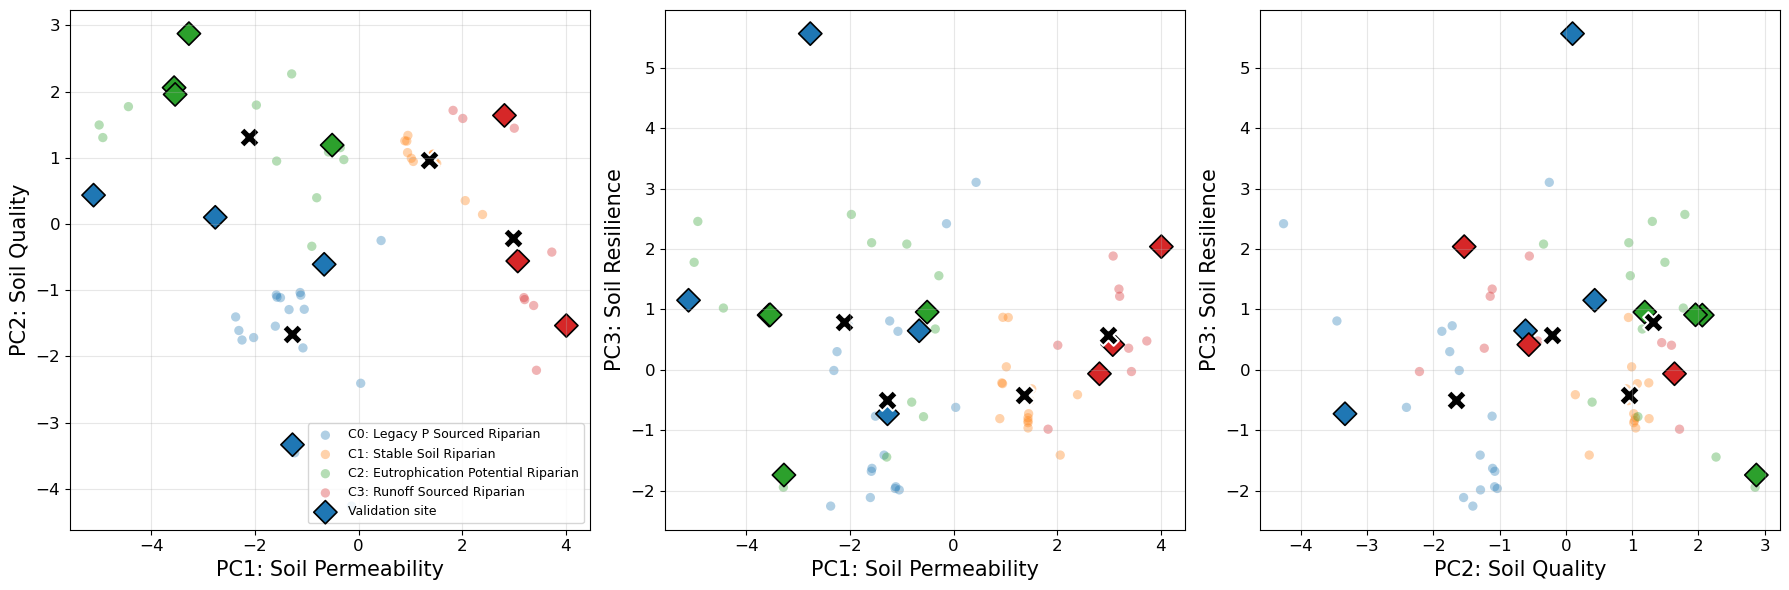

In [4]:
# --- Visualization: validation sites (diamonds) over the trained clusters ---
Zt, lt = M["train_scores"], M["train_labels"]
pairs = [(0, 1), (0, 2), (1, 2)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (a, b) in zip(axes, pairs):
    for c in range(M["k"]):
        m = lt == c
        ax.scatter(Zt[m, a], Zt[m, b], c=[PALETTE[c]], s=45, alpha=.35,
                   edgecolors="none", label=f"C{c}: {CLUSTER_NAMES[c]}")
    ax.scatter(scores_v[:, a], scores_v[:, b],
               c=[PALETTE[c] for c in val["Cluster"]], s=140, marker="D",
               edgecolors="black", linewidth=1.2, label="Validation site")
    ax.scatter(centroids[:, a], centroids[:, b], c="black", marker="X", s=220,
               edgecolors="white", linewidth=1.5)
    ax.set(xlabel=f"PC{a+1}: {PC_NAMES[f'PC{a+1}']}",
           ylabel=f"PC{b+1}: {PC_NAMES[f'PC{b+1}']}")
    ax.grid(alpha=.3)
axes[0].legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "validation-projection.png", dpi=200)
plt.show()

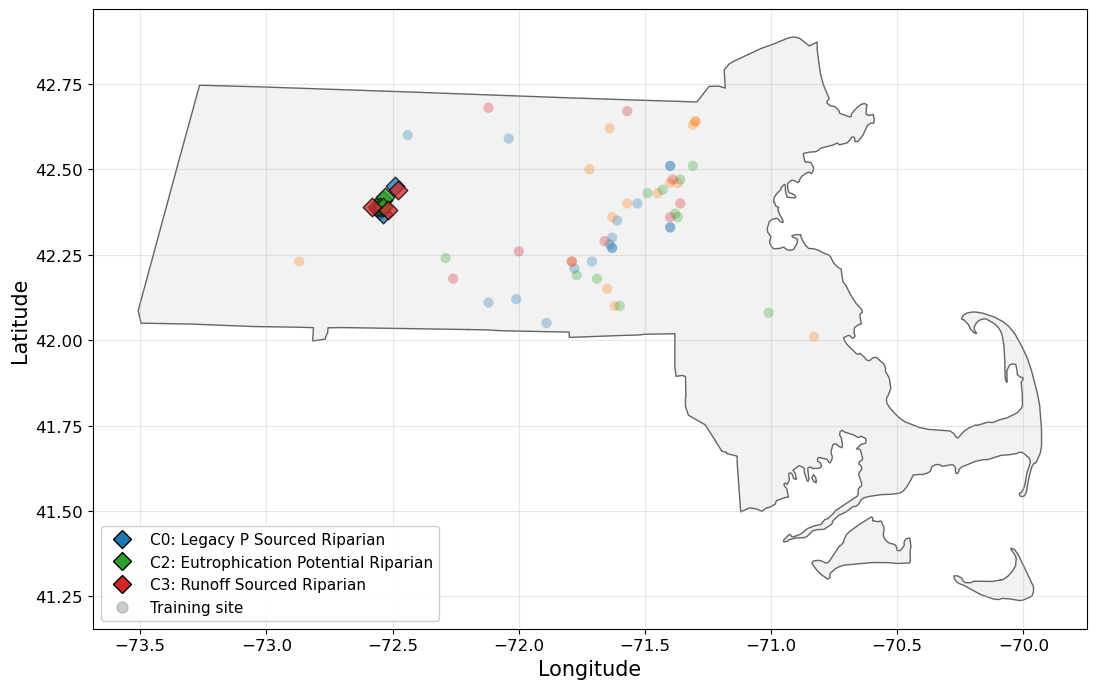

In [5]:
# --- Validation site map: held-out stations (diamonds) over Massachusetts ---
import json
from matplotlib.lines import Line2D

ma = json.load(open(ROOT / "data" / "geo" / "massachusetts.geojson"))
train_lab = pd.read_csv(OUT / "typology-training-labeled.csv")   # training coords + Cluster

def iter_rings(geom):
    if geom["type"] == "Polygon":
        yield from geom["coordinates"]
    else:
        for poly in geom["coordinates"]:
            yield from poly

fig, ax = plt.subplots(figsize=(12, 7))
for ring in iter_rings(ma["geometry"]):
    xs, ys = zip(*ring)
    ax.fill(xs, ys, color="0.95", zorder=0)
    ax.plot(xs, ys, color="0.4", lw=1, zorder=1)

# training sites as faint context
for c in range(M["k"]):
    m = train_lab["Cluster"] == c
    ax.scatter(train_lab.loc[m, "Longitude"], train_lab.loc[m, "Latitude"],
               c=[PALETTE[c]], s=55, alpha=.30, edgecolors="none", zorder=2)

# validation sites as diamonds, colored by assigned type
for c in range(M["k"]):
    m = val["Cluster"] == c
    if m.any():
        ax.scatter(val.loc[m, "Longitude"], val.loc[m, "Latitude"],
                   c=[PALETTE[c]], s=90, marker="D", alpha=.75,
                   edgecolors="black", linewidth=1.0, zorder=3)

handles = [Line2D([], [], marker="D", color=PALETTE[c], ls="", markersize=9,
                  markeredgecolor="black", label=f"C{c}: {CLUSTER_NAMES[c]}")
           for c in sorted(val["Cluster"].unique())]
handles.append(Line2D([], [], marker="o", color="0.6", ls="", markersize=8,
                      alpha=.5, label="Training site"))
ax.set_aspect(1 / np.cos(np.deg2rad(val["Latitude"].mean())))
ax.set(xlabel="Longitude", ylabel="Latitude")
ax.legend(handles=handles, loc="lower left", framealpha=.95)
ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIG / "validation-site-map.png", dpi=200, bbox_inches="tight")
plt.show()

In [6]:
# --- Characterize the validation sites and save results ---
vprofile = val.groupby("Cluster")[FEATURES].mean().T
vprofile.index = [VARIABLE_LABELS.get(f, f) for f in vprofile.index]
vprofile.columns = [f"C{c}: {CLUSTER_NAMES[c]}" for c in vprofile.columns]
print("Mean feature profile of validation sites by assigned type:")
print(vprofile.round(2).to_string())

val[ID_COLS + FEATURES + ["Cluster", "Type", "Dist_to_centroid"]].to_csv(
    OUT / "validation-labeled.csv", index=False)
print("\nSaved validation-labeled.csv to", OUT)

Mean feature profile of validation sites by assigned type:
                                          C0: Legacy P Sourced Riparian  C2: Eutrophication Potential Riparian  C3: Runoff Sourced Riparian
Geometric Mean TP (µg/L)                                          61.97                                  69.60                        30.93
TP Sen Slope (µg/L)                                               -3.82                                  -2.18                        -1.33
Soil Tolerance Factor                                              3.75                                   4.50                         3.67
Available Water Storage 0-100 cm                                  14.08                                  17.90                         6.89
Available Water Storage 0-25 cm                                    4.38                                   4.88                         2.67
Depth to Water Table (cm)                                         30.00                              